# A simple notebook to perform binary classification on a comprehensive pokemon dataset to figure whether a given specimen is legendary or not
# Dataset taken from Kaggle - https://www.kaggle.com/datasets/rounakbanik/pokemon

In [1]:
# ----------------------------------------------------------------------------------------
# Import basic libraries
# ----------------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import ast

# ----------------------------------------------------------------------------------------
# Import graphic libraries
# ----------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------------------
# Import scikit-learn libraries
# ----------------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Project Constants

In [2]:
# ----------------------------------------------------------------------------------------
# global constants
# ----------------------------------------------------------------------------------------
random_seed = 42

# ----------------------------------------------------------------------------------------
# dataset constants
# ----------------------------------------------------------------------------------------
dataset_cvs_filename = "pokemon.csv"
dataset_cvs_delimiter_char = ','
dataset_cvs_num_rows_read = None # specify 'None' if want to read whole file

label_classification = 'is_legendary'

# ----------------------------------------------------------------------------------------
# machine learning constants
# ----------------------------------------------------------------------------------------
ml_cv_folds = 5
ml_scoring_metric = 'accuracy'

# train test split constants
test_train_split_rate = 0.2
test_train_split_random_state = random_seed

# random forrest constants
rf_random_state = random_seed

# grid search random forrest constants 
rf_grid_search_cv_folds = ml_cv_folds
rf_grid_search_scoring = ml_scoring_metric
rf_grid_search_random_state = random_seed

# XGBoost constants
xgboost_random_state = random_seed

# Grid search XGBoost constants
xgboost_grid_search_cv_folds = ml_cv_folds
xgboost_grid_search_scoring = ml_scoring_metric
xgboost_grid_search_random_state = random_seed

## Project Utility Routines

In [3]:
# Display Dataset Distribution Graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [4]:
# Dataset Correlation matrix
def plotCorrelationMatrix(df, graphWidth, title):
    df = df.dropna(axis='columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {title}', fontsize=15)
    plt.show()

## Dataset Loading and Exploration

In [5]:
# load dataset from cvs file
try:
    df = pd.read_csv(dataset_cvs_filename, delimiter=dataset_cvs_delimiter_char, nrows = dataset_cvs_num_rows_read)
    num_rows, num_columns = df.shape
except Exception as e:
    print("⚠️ Unable to load Pokemon dataset.")
    exit(0)

print(f"✅ Pokemon dataset has been succefully loaded: there are {num_rows} rows and {num_columns} columns.\n")

✅ Pokemon dataset has been succefully loaded: there are 801 rows and 41 columns.



In [6]:
# sanity checks for the classification column
df_labels = df[label_classification]

if df_labels.isnull().sum() != 0:
    print(f"⚠️ The Pokemon dataset is not actionable, there are null value in the '{label_classification}' column.")
    exit(0)
if df_labels.dtype != 'int64':
    print(f"⚠️ The Pokemon dataset is not actionable, there are null value in the '{label_classification}' column.")
    exit(0)

num_pokemon_legendary = df_labels.value_counts().get(1)
num_pokemon_non_legendary = df_labels.value_counts().get(0)

if num_pokemon_legendary + num_pokemon_non_legendary != len(df):
    print(f"⚠️ The Pokemon dataset is not actionable, the '{label_classification}' column contains values different than zero or one.")

print(f"✅ There are {num_pokemon_legendary} legendary pokemon in the dataset ({num_pokemon_legendary/len(df)*100:.2f}%).")

✅ There are 70 legendary pokemon in the dataset (8.74%).


In [7]:
# display first rows
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [8]:
# features
df_features = df.drop(label_classification, axis=1)

# display numerical and categorical columns 
numerical_features = df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features: {numerical_features}.")

categorical_features = df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features: {categorical_features}.")

Numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'defense', 'experience_growth',
       'height_m', 'hp', 'percentage_male', 'pokedex_number', 'sp_attack',
       'sp_defense', 'speed', 'weight_kg', 'generation'],
      dtype='object').
Categorical Features: Index(['abilities', 'capture_rate', 'classfication', 'japanese_name', 'name',
       'type1', 'type2'],
      dtype='object').


## First observations from dataset exploration: 
    - 'japanese_name', 'name' : colmuns will be dropped, japanaese names or names should not influence legendary classification
    - 'pokedex_number' : column will be dropped, index of appearance in pokemodex should not influence legendary classification 
    - 'capture_rate' : need to check values, should be a numerical column
    - 'abilities' : multi-values string describing 'features' of pokemons. These information need therefore special processing to be transformed to proper column 

In [9]:
# Explore the null values in the dataset
df.isnull().sum().sort_values(ascending=False)

type2                384
percentage_male       98
weight_kg             20
height_m              20
name                   0
capture_rate           0
classfication          0
defense                0
experience_growth      0
hp                     0
japanese_name          0
abilities              0
base_happiness         0
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
generation             0
base_total             0
base_egg_steps         0
against_bug            0
attack                 0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0


## Second observations from dataset exploration: 
    - 'type2' : the colmun will be dropped, this is a sub-type ('string' type) of pokemon so imputation strategy is irrelevant
    - 'percentage_male' : null values will be replaced with a neutral value, i.e. 50.0
    - 'weight_kg', 'height_m' : null value wil be replaced with average value

In [10]:
# drop unactionable columns for prediction
actionable_df_features = df_features.drop(['japanese_name', 'name', 'type2', 'pokedex_number'], axis=1)
actionable_num_rows, actionable_num_columns = actionable_df_features.shape

print(f"✅ The Pokemon actionable dataset has {actionable_num_columns} feature colmuns.")

# recompute numerical and categorical features 
actionable_numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Actionable numerical Features: {actionable_numerical_features}.")

actionable_categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Actionable categorical Features: {actionable_categorical_features}.")

✅ The Pokemon actionable dataset has 36 feature colmuns.
Actionable numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'defense', 'experience_growth',
       'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed',
       'weight_kg', 'generation'],
      dtype='object').
Actionable categorical Features: Index(['abilities', 'capture_rate', 'classfication', 'type1'], dtype='object').


In [11]:
# check unexpected typed column 'capture_rate' : type is 'object' but should it be 'int64' or 'float64' instead?
df_capture_rate = actionable_df_features['capture_rate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 801 entries, 0 to 800
Series name: capture_rate
Non-Null Count  Dtype 
--------------  ----- 
801 non-null    object
dtypes: object(1)
memory usage: 6.4+ KB


In [12]:
# check wether 'capture_rate' values are actually numerical, if not replace them by None
for idx in range(0, len(actionable_df_features['capture_rate'])):
    try:
        val = float(actionable_df_features['capture_rate'].at[idx])
    except Exception as e:
        print(f"⚠️ An anomaly has been found in the 'capture_rate' column at index '{idx}': value '{actionable_df_features['capture_rate'].at[idx]}' has been replaced by 'None'.")
        actionable_df_features['capture_rate'].at[idx] = None

print(f"⚠️ Number of anomalies found : {actionable_df_features['capture_rate'].isnull().sum()}")

⚠️ An anomaly has been found in the 'capture_rate' column at index '773': value '30 (Meteorite)255 (Core)' has been replaced by 'None'.
⚠️ Number of anomalies found : 1


In [13]:
# now convert 'capture_rate' column to float64
actionable_df_features['capture_rate'] =  actionable_df_features['capture_rate'].astype('float64')

In [14]:
# recompute numerical and categorical features 
numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features: {numerical_features}.")

categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features: {categorical_features}.")

Numerical Features: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'capture_rate', 'defense',
       'experience_growth', 'height_m', 'hp', 'percentage_male', 'sp_attack',
       'sp_defense', 'speed', 'weight_kg', 'generation'],
      dtype='object').
Categorical Features: Index(['abilities', 'classfication', 'type1'], dtype='object').


In [15]:
# Explore the null values in the dataset
actionable_df_features.isnull().sum().sort_values(ascending=False)

percentage_male      98
height_m             20
weight_kg            20
capture_rate          1
experience_growth     0
base_egg_steps        0
base_happiness        0
base_total            0
classfication         0
defense               0
abilities             0
against_bug           0
hp                    0
sp_attack             0
sp_defense            0
speed                 0
type1                 0
attack                0
against_water         0
against_steel         0
against_flying        0
against_dark          0
against_dragon        0
against_electric      0
against_fairy         0
against_fight         0
against_fire          0
against_ghost         0
against_rock          0
against_grass         0
against_ground        0
against_ice           0
against_normal        0
against_poison        0
against_psychic       0
generation            0
dtype: int64

## Third observation from dataset exploration: 
    - 'capture_rate' : null values will be replaced with a neutral value, i.e. 50.0

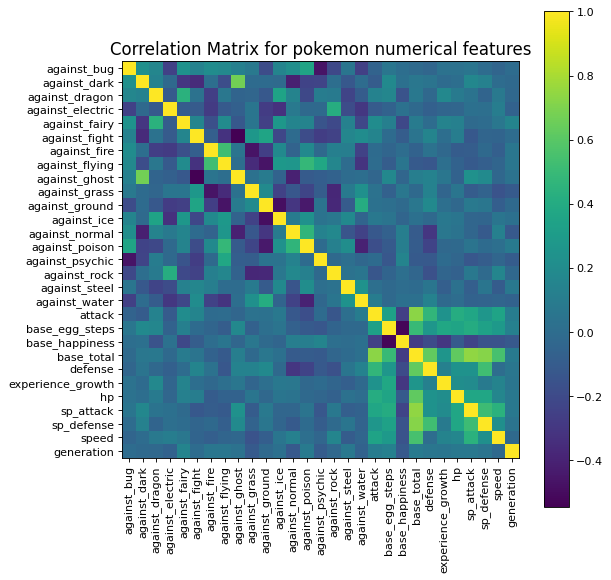

In [16]:
# Display correlation matrix of numerical features
plotCorrelationMatrix(actionable_df_features.drop(columns=categorical_features), 8, "pokemon numerical features")

In [17]:
# Now explore the 'abilities' column
actionable_df_features['abilities']

0      ['Overgrow', 'Chlorophyll']
1      ['Overgrow', 'Chlorophyll']
2      ['Overgrow', 'Chlorophyll']
3         ['Blaze', 'Solar Power']
4         ['Blaze', 'Solar Power']
                  ...             
796                ['Beast Boost']
797                ['Beast Boost']
798                ['Beast Boost']
799                ['Prism Armor']
800                 ['Soul-Heart']
Name: abilities, Length: 801, dtype: object

In [18]:
num_rows, num_columns = actionable_df_features.shape
print(f"Before the 'abilities' transformation, Pokemon dataset contains {num_rows} rows and {num_columns} columns.")

# Explode the multi-abilities string values into lists of abilities 
actionable_df_features['abilities'] = actionable_df_features['abilities'].apply(ast.literal_eval)

# Generate a dataframe where each column represents a unique abiltity found in the previous 'abilities' column
# join('|') temporarily transforms a list into a '|' delimiter separated string; 
# get_dummies finds all unique elements separately and builds columns with 0 or 1 values
new_abilities = actionable_df_features['abilities'].str.join('|').str.get_dummies()

# Drop the 'abilities' original column 
actionable_df_features = actionable_df_features.drop(labels=['abilities'], axis=1)

# concatenate the new dataframe 
actionable_df_features = pd.concat([actionable_df_features, new_abilities], axis=1)

num_rows, num_columns = actionable_df_features.shape
print(f"✅ After the 'abilities' transformation, actionable Pokemon dataset contains {num_rows} rows and {num_columns} columns.")

Before the 'abilities' transformation, Pokemon dataset contains 801 rows and 36 columns.
✅ After the 'abilities' transformation, actionable Pokemon dataset contains 801 rows and 262 columns.


In [19]:
actionable_df_features.head()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,Water Absorb,Water Bubble,Water Compaction,Water Veil,Weak Armor,White Smoke,Wimp Out,Wonder Guard,Wonder Skin,Zen Mode
0,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
1,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,0,0,0,0,0,0,0,0,0,0
3,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,0,0,0,0,0,0,0,0,0,0
4,0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# recompute numerical and categorical features 
numerical_features = actionable_df_features.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features ({len(numerical_features)}): {numerical_features}.")

categorical_features = actionable_df_features.select_dtypes(include=['object']).columns
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}.")

Numerical Features (260): Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass',
       ...
       'Water Absorb', 'Water Bubble', 'Water Compaction', 'Water Veil',
       'Weak Armor', 'White Smoke', 'Wimp Out', 'Wonder Guard', 'Wonder Skin ',
       'Zen Mode'],
      dtype='object', length=260).
Categorical Features (2): Index(['classfication', 'type1'], dtype='object').


In [21]:
# Explore the null values in the dataset
actionable_df_features.isnull().sum().sort_values(ascending=False)

percentage_male    98
height_m           20
weight_kg          20
capture_rate        1
against_bug         0
                   ..
Galvanize           0
Gluttony            0
Gooey               0
Grass Pelt          0
Zen Mode            0
Length: 262, dtype: int64

## Summary of Observations
   - 'percentage_male', 'capture_rate' : replace null value by neutral 50.0 valaue
   - 'height_m', 'weight_kg' : replace null value by average of column

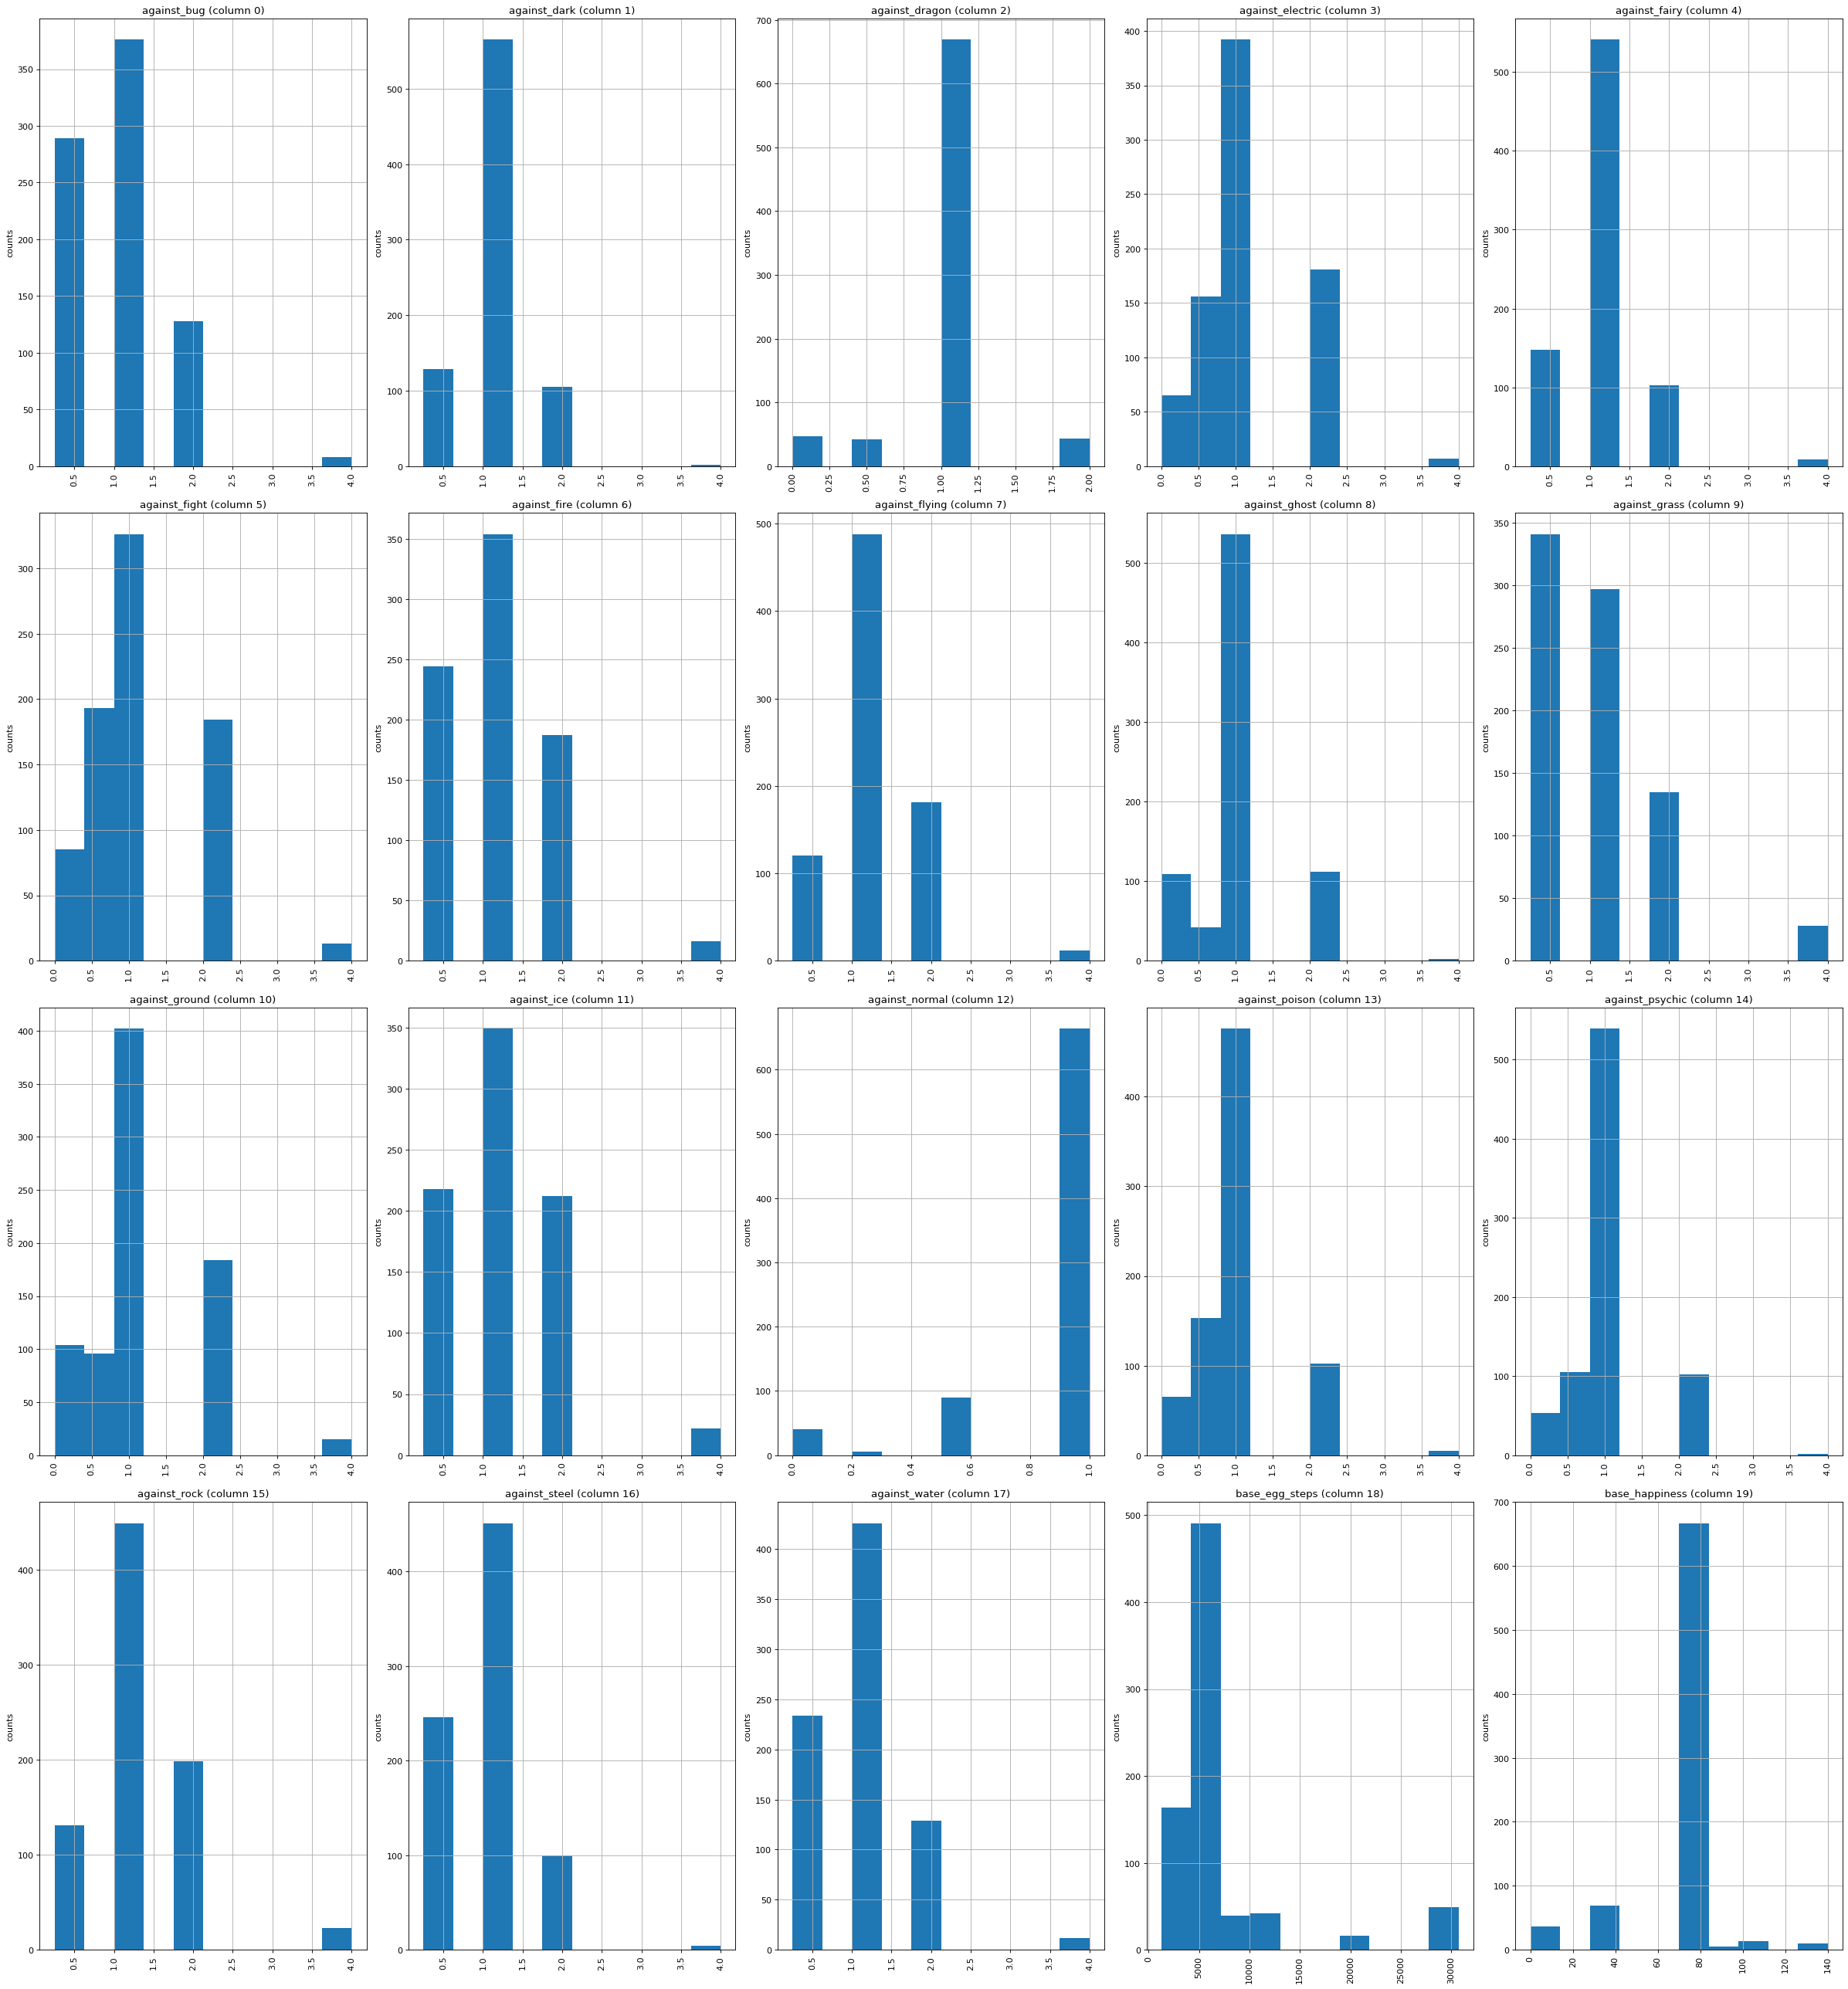

In [22]:
# show distribution of columns
plotPerColumnDistribution(actionable_df_features, 20, 5)

In [23]:
# dataframe cleaned and preped for training 
X = actionable_df_features
y = df_labels

num_rows, num_columns = X.shape
print(f"✅ The Pokemon dataset has been cleaned and prepared for training, itcontains {num_rows} rows and {num_columns} columns.")

# recompute numerical and categorical features 
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Features ({len(numerical_features)}): {numerical_features.to_list()}.")

categorical_features = X.select_dtypes(include=['object']).columns
print(f"Categorical Features ({len(categorical_features)}): {categorical_features.to_list()}.")

✅ The Pokemon dataset has been cleaned and prepared for training, itcontains 801 rows and 262 columns.
Numerical Features (260): ['against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'defense', 'experience_growth', 'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'generation', 'Adaptability', 'Aftermath', 'Air Lock', 'Analytic', 'Anger Point', 'Anticipation', 'Arena Trap', 'Aroma Veil', 'Aura Break', 'Bad Dreams', 'Battery', 'Battle Armor', 'Battle Bond', 'Beast Boost', 'Berserk', 'Big Pecks', 'Blaze', 'Bulletproof', 'Cheek Pouch', 'Chlorophyll', 'Clear Body', 'Cloud Nine', 'Color Change', 'Comatose', 'Competitive', 'Compou